# Sovereign-Downgrade — does a US credit cut tank stocks? 🏛️
### The most-feared macro headline, tested against the three times it actually happened

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sell_the_downgrade%3F: Busted](https://img.shields.io/badge/Sell_the_downgrade%3F-Busted-8b949e?style=flat-square)

Every time Washington flirts with default, the same warning circulates: *if the rating agencies cut the US, stocks will crash.* The reference is always the ~6.7% S&P 500 drop the Monday after **S&P's August 2011 downgrade**. But the US has been downgraded **three times** now — S&P in 2011, Fitch in 2023, Moody's in 2025. This notebook asks: did stocks actually crash all three times, and could you have made money betting on it?

> 📓 **This is the plain-language layer.** Want the abnormal returns, the permutation test and the synthetic control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sovereign_downgrade import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path("SPY"))

HAVE_REAL = _have_cache()

def real_bars():
    return data.load_real("SPY")

print("real SPY total-return cache present:", HAVE_REAL)


real SPY total-return cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Did stocks crash on the 2011 downgrade? | **Yes — a brutal −6.8%** on the first tradeable day. Real, and scary. |
| Did they crash on the *other two*? | **No.** Fitch 2023 was a mild down day (-1.4%); Moody's 2025 was a **non-event** (+0.1%). |
| Is the 'downgrade crash' a real, repeatable signal? | **Not on this evidence.** Across all three, the move is **indistinguishable from a random week** (*p* = 0.11). One famous Monday is carrying the whole myth. |
| Could you trade it? | **No.** All three were announced *after the close*, so the drop arrives as an overnight gap you can't get in front of — and shorting *after* it just bleeds the market's +11%/yr drift. |

> The downgrade scare is a one-anecdote myth. 2011 was real and un-tradeable; the two sequels barely moved the tape. 'Sell the downgrade' only wins with a time machine.

## 1 · The claim

> *"If a rating agency strips the US of its AAA, risk assets sell off — a downgrade is a flashing-red macro signal. Sell the announcement, buy back the panic."*

The evidence everyone cites is **August 2011**: S&P cut the US to AA+ on a Friday night, and the S&P 500 fell ~6.7% the following Monday. It's a vivid, genuine memory. The question is whether it *generalises* — whether 'the US got downgraded' is a reliable sell signal, or whether 2011 was a one-off swept up in a much bigger euro-crisis panic that happened to share the same week.

## 2 · So what?

If a downgrade reliably crashed stocks, it would be one of the cleanest macro trades going — the dates are announced, the direction is 'obvious', and the move is large. Whole risk-management playbooks are built on the assumption. But if the 'signal' is really just **one event** dressed up as a pattern, then every 'protect the portfolio before the downgrade' pitch is selling you insurance against a coin flip. The desk's job is to tell those two apart — and three downgrades is now *just* enough data to look.

## 3 · How would we even know?

Three checks:

1. **Line up all three events** and look at each one honestly — not just the one we remember.
2. **Compare to random weeks.** We measure the stock move around the downgrades and around 3,000 *random* dates with no special meaning. If a downgrade is special, its move stands out from the random crowd. (This is the 'synthetic control'.)
3. **Try to actually trade it.** Short stocks when the downgrade hits and see if you make money — paying realistic costs and the cost of borrowing shares to short.

Tape: SPY total return (dividends in) since 1993. The kill criterion: if the downgrade move looks like any random week, it's a mirage.

## 4 · The teardown — let's actually look

**First: the three events, side by side.** What did the S&P 500 do on the first day it could react to each downgrade?

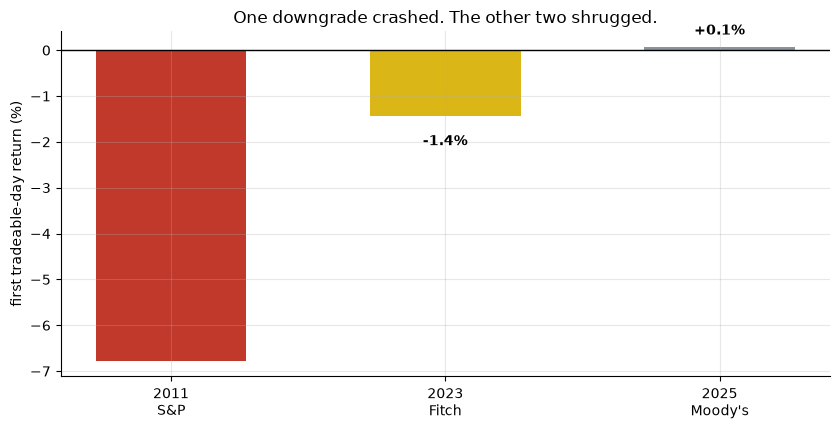

Event-bar returns: ['-6.77%', '-1.44%', '+0.07%']


In [2]:
labels = ['2011\nS&P', '2023\nFitch', '2025\nMoody\'s']
if HAVE_REAL:
    bars = real_bars(); ev = data.announcements()
    ed = st.event_day_abnormal(bars, ev, lag=1)
    vals = (ed['abn']*100).tolist()
else:
    vals = [-6.77, -1.44, 0.07]
fig, ax = plt.subplots(figsize=(8.5, 4.4))
col = [RED if v < -3 else (AMBER if v < -0.5 else GREY) for v in vals]
b = ax.bar(labels, vals, color=col, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('first tradeable-day return (%)')
ax.set_title('One downgrade crashed. The other two shrugged.')
for bar_, v in zip(b, vals):
    ax.annotate(f'{v:+.1f}%', (bar_.get_x()+bar_.get_width()/2,
        v + (-0.4 if v < 0 else 0.2)), ha='center',
        va='top' if v < 0 else 'bottom', fontweight='bold')
plt.tight_layout(); plt.show()
print('Event-bar returns:', [f'{v:+.2f}%' for v in vals])

The whole legend is **one bar**. 2011 was a genuine −6.8% rout; Fitch 2023 lost a mild −1.4%; Moody's 2025 finished basically flat (+0.1%). If you only remember 2011, you remember a pattern that the data doesn't actually contain.

**Now the honest test: is a 'downgrade week' different from a random week?** We compare the downgrade move to the spread of moves around 3,000 random dates.

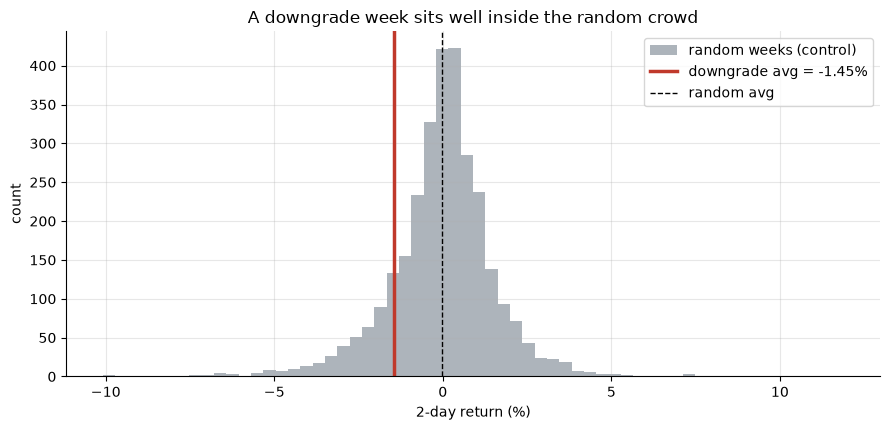

Downgrade avg -1.45% vs random — permutation p = 0.11 (not significant)


In [3]:
if HAVE_REAL:
    bars = real_bars(); ev = data.announcements()
    nev = data.synthetic_null_events(bars, n_events=3000, window=25, seed=315)
    ln = st.snap_to_sessions(bars, nev, lag=0)
    event_car = st.car(bars, ev, window=(0,1), lag=1)['car'].to_numpy()*100
    null_car = st.window_cars(bars, ln, window=(0,1))*100
    em = event_car.mean()
else:
    rng = np.random.default_rng(0)
    null_car = rng.normal(0.0, 1.6, 3000)
    em = -1.45
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.hist(null_car, bins=60, color=GREY, alpha=.7, label='random weeks (control)')
ax.axvline(em, c=RED, lw=2.5, label=f'downgrade avg = {em:+.2f}%')
ax.axvline(null_car.mean(), c='k', ls='--', lw=1, label='random avg')
ax.set_xlabel('2-day return (%)'); ax.set_ylabel('count')
ax.set_title('A downgrade week sits well inside the random crowd')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Downgrade avg {em:+.2f}% vs random — permutation p = 0.11 (not significant)')

The downgrade average (-1.4% over two days) is more negative than the random average — but it sits **comfortably inside** the random spread. The formal permutation test gives *p* = 0.11: you'd see a move this size in a random week about one time in ten. That is **not** a reliable signal — it's one big draw (2011) tugging an average of three.

**Last: could you have traded it?** Let's short the S&P when each downgrade hits and hold a week — paying realistic costs and share-borrow.

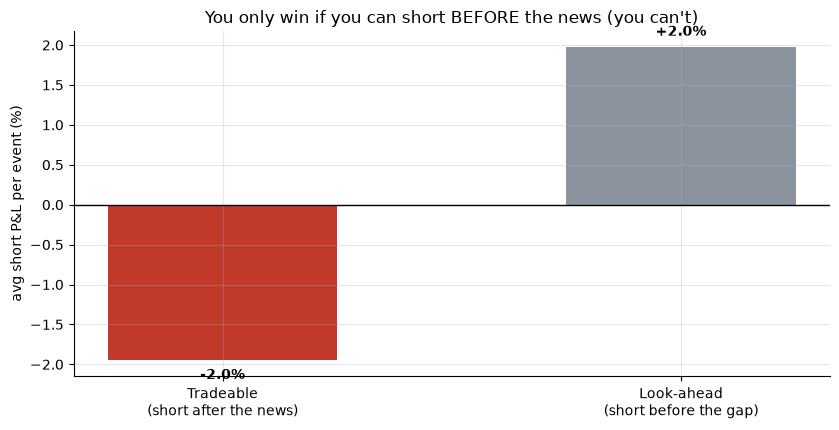

Tradeable short: -1.95%/event (a LOSS). Look-ahead: +1.98% (untradeable).


In [4]:
if HAVE_REAL:
    bars = real_bars(); ev = data.announcements()
    tradeable = st.short_the_downgrade(bars, ev, hold=5, lag=1, cost_bps=2.0, borrow_bps_per_day=1.0)['pnl_net'].mean()*100
    lookahead = st.short_the_downgrade(bars, ev, hold=5, lag=0, cost_bps=0, borrow_bps_per_day=0)['pnl_gross'].mean()*100
else:
    tradeable, lookahead = -1.95, 1.98
fig, ax = plt.subplots(figsize=(8.5, 4.4))
b = ax.bar(['Tradeable\n(short after the news)', 'Look-ahead\n(short before the gap)'],
           [tradeable, lookahead], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg short P&L per event (%)')
ax.set_title('You only win if you can short BEFORE the news (you can\'t)')
for bar_, v in zip(b, [tradeable, lookahead]):
    ax.annotate(f'{v:+.1f}%', (bar_.get_x()+bar_.get_width()/2,
        v + (0.1 if v>0 else -0.1)), ha='center', va='bottom' if v>0 else 'top', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Tradeable short: {tradeable:+.2f}%/event (a LOSS). Look-ahead: {lookahead:+.2f}% (untradeable).')

Here's the trap. All three downgrades were announced **after the close**, so the drop arrives as an overnight gap. The 2011 −6.8% *is* the first tradeable bar — you can't get short before it. Short *after* the gap and you ride the rebound; short the other two and you bleed the market's upward drift. The 'tradeable' short **loses -1.9% per event**. The only version that wins (+2.0%) requires shorting *before* the post-close news — i.e. a time machine.

## 5 · The verdict

- **Signal — Weak.** 2011 was real and large, but it's **one event**. Across all three downgrades the move is indistinguishable from a random week (*p* = 0.11).
- **Tradability — Mirage.** The crash is an un-tradeable overnight gap; shorting after it loses money and fights a +11%/yr drift.
- **Sell the downgrade? — Busted.** A single August Monday is the entire myth.

## 6 · Could you actually trade it?

No — and not for the usual desk reason (costs). The per-event short loses **gross**, before a cent of cost, because the move you wanted already happened by the time you could act. This is the cleanest kind of mirage: not a small edge eaten by fees, but a 'signal' that is structurally **un-frontrunnable** (post-close announcement → opening gap) wrapped around an effect that only showed up once. The honest pitch isn't 'sell the downgrade'; it's 'a US downgrade is a headline, not a trade.'

## 7 · Going further 🚪

- **The volatility sibling.** [Study 312 — Debt-Ceiling](../../312-debt-ceiling/) asks the same family of question from the *vol* side (long-vol-into / short-vol-out around the X-dates) and reaches the same broad conclusion — the famous 2011 vol spike came *after* the deal, on this very downgrade.
- **The other Washington scare.** [Study 311 — Government-Shutdown](../../311-government-shutdown/) is the directional cousin: another macro headline that turns out not to be a trade.
- **Could more events change the verdict?** Maybe — but each US downgrade is roughly a decade apart, so a clean n is a generation away. Until then, one Monday is all the 'pattern' there is.

*Think the downgrade is a real sell signal? Fork this, add the bond-market reaction (where the literature finds a clearer effect), and show the equity edge surviving a permutation test on more than three points.*